In [235]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression

In [236]:
data = pd.read_excel('transport_data.xlsx')
data

,ДАТА,КУРС_ДАТА,ВЪЗЛОЖИТЕЛ,КУРС,БРОЙ_ОБЕКТИ,ПРЕВОЗВАЧ,ШОФЬОР,ВЛЕКАЧ,ЦИСТЕРНА,КМ,...,ТОЛ_РАЗХОДИ,ЗАРЕДЕНО_ГОРИВО,ДРУГИ_РАЗХОДИ,СЪЗДАТЕЛ,СЪЗДАДЕНО_НА,ПРОМЯНА_ОТ,ПОСЛЕДЕН_ЪПДЕЙТ,ГОДИНА,МЕСЕЦ,ДЕН
0,20260127-0001,2026-01-26,ОФИС ВАРНА,Русе-Тервел-Русе,NaN,ЕВРОУЕЙ СЪРВИЗ ООД,ДАНИЕЛ ПЕНЧЕВ ПЕНЧЕВ,Р7826КН,Р2530ЕЕ,300.0,...,NaN,NaN,NaN,Vesela Nikolova,2026-01-27 07:48:35.139,Plamen Svetoslavov,2026-04-01 18:48:15.743,2026,1,27
1,20260127-0002,2026-01-27,ОФИС ВАРНА,Варна-Риш-Нефтохим,NaN,ЕВРОУЕЙ СЪРВИЗ ООД,ГЕОРГИ ИЛИЕВ ГЕОРГИЕВ,Р9581МА,Р4961ЕЕ,250.0,...,NaN,NaN,NaN,Vesela Nikolova,2026-01-27 16:36:41.699,Plamen Svetoslavov,2026-04-01 18:48:17.024,2026,1,27
2,20260127-0003,2026-01-28,ОФИС ВАРНА,Нефтохим-Варна-Добрич-Караплит-Подайва-Варна,NaN,ЕВРОУЕЙ СЪРВИЗ ООД,ГЕОРГИ ИЛИЕВ ГЕОРГИЕВ,Р9581МА,Р4961ЕЕ,420.0,...,NaN,NaN,NaN,Vesela Nikolova,2026-01-27 16:39:22.266,Plamen Svetoslavov,2026-04-01 18:48:17.024,2026,1,27
3,20260128-0001,2026-01-29,ОФИС ВАРНА,Варна-Шабла-Варна,NaN,ЕВРОУЕЙ СЪРВИЗ ООД,ГЕОРГИ ИЛИЕВ ГЕОРГИЕВ,Р9581МА,NaN,180.0,...,NaN,NaN,NaN,Vesela Nikolova,2026-01-28 15:39:15.844,Plamen Svetoslavov,2026-04-01 18:48:17.024,2026,1,28
4,20260129-0001,2026-01-30,ОФИС ВАРНА,Варна-НХК-Повеляново-Добрич-Русе,NaN,ЕВРОУЕЙ СЪРВИЗ ООД,ДАНИЕЛ ПЕНЧЕВ ПЕНЧЕВ,Р7826КН,Р2530ЕЕ,560.0,...,NaN,NaN,NaN,Vesela Nikolova,2026-01-29 11:09:16.459,Plamen Svetoslavov,2026-04-01 18:48:17.024,2026,1,29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88,20260401-0008,2026-02-13,ОФИС СОФИЯ,Бяла-Русе,NaN,ЕВРОУЕЙ СЪРВИЗ ООД,ПАВЕЛ СТЕФАНОВ ГЕОРГИЕВ,CB2201CC,P2849EE,50.0,...,NaN,NaN,NaN,Vesela Nikolova,2026-04-01 10:46:49.509,Vesela Nikolova,2026-04-01 19:44:10.434,2026,4,1
89,20260401-0009,2026-02-17,ОФИС СОФИЯ,Русе-Павликени-Ловеч-д.Луковит-Русе,NaN,ЕВРОУЕЙ СЪРВИЗ ООД,ПАВЕЛ СТЕФАНОВ ГЕОРГИЕВ,CB2201CC,P2849EE,440.0,...,NaN,NaN,NaN,Vesela Nikolova,2026-04-01 10:48:25.015,Vesela Nikolova,2026-04-01 19:44:12.091,2026,4,1
90,20260401-0010,2026-02-23,ОФИС СОФИЯ,Русе-Плевен-София,NaN,ЕВРОУЕЙ СЪРВИЗ ООД,ПАВЕЛ СТЕФАНОВ ГЕОРГИЕВ,Р9581МА,Р4961ЕЕ,320.0,...,NaN,NaN,NaN,Vesela Nikolova,2026-04-01 11:07:48.212,Vesela Nikolova,2026-04-01 19:44:16.959,2026,4,1
91,20260401-0011,2026-02-24,ОФИС СОФИЯ,София-Радомир-Плевен,NaN,ЕВРОУЕЙ СЪРВИЗ ООД,ПАВЕЛ СТЕФАНОВ ГЕОРГИЕВ,Р9581МА,Р4961ЕЕ,270.0,...,NaN,NaN,NaN,Vesela Nikolova,2026-04-01 11:11:48.883,Vesela Nikolova,2026-04-01 19:44:18.275,2026,4,1


## Л_на_КМ (литри на километър)

### Какво представлява:
Л_на_КМ = превозен товар (литри) / изминато разстояние (км)

---

### Какво показва:
Показва колко ефективно се използва транспортът, т.е. колко товар се превозва за всеки 1 км.

---

### Как се тълкува:

- Висока стойност → ефективен курс
  (превозва се много товар на малко разстояние)

- Ниска стойност → неефективен курс
  (малко товар за много километри → празни курсове)

---

### Извод:
Това е основен показател за оценка на ефективността на транспортните операции.

In [237]:
data['Л_на_КМ'] = data['Л'] / data['КМ']
data = data[data['КМ'] > 0].copy()
data['log_KM'] = np.log(data['КМ'])

In [238]:
data

,ДАТА,КУРС_ДАТА,ВЪЗЛОЖИТЕЛ,КУРС,БРОЙ_ОБЕКТИ,ПРЕВОЗВАЧ,ШОФЬОР,ВЛЕКАЧ,ЦИСТЕРНА,КМ,...,ДРУГИ_РАЗХОДИ,СЪЗДАТЕЛ,СЪЗДАДЕНО_НА,ПРОМЯНА_ОТ,ПОСЛЕДЕН_ЪПДЕЙТ,ГОДИНА,МЕСЕЦ,ДЕН,Л_на_КМ,log_KM
0,20260127-0001,2026-01-26,ОФИС ВАРНА,Русе-Тервел-Русе,NaN,ЕВРОУЕЙ СЪРВИЗ ООД,ДАНИЕЛ ПЕНЧЕВ ПЕНЧЕВ,Р7826КН,Р2530ЕЕ,300.0,...,NaN,Vesela Nikolova,2026-01-27 07:48:35.139,Plamen Svetoslavov,2026-04-01 18:48:15.743,2026,1,27,106.666667,5.703782
1,20260127-0002,2026-01-27,ОФИС ВАРНА,Варна-Риш-Нефтохим,NaN,ЕВРОУЕЙ СЪРВИЗ ООД,ГЕОРГИ ИЛИЕВ ГЕОРГИЕВ,Р9581МА,Р4961ЕЕ,250.0,...,NaN,Vesela Nikolova,2026-01-27 16:36:41.699,Plamen Svetoslavov,2026-04-01 18:48:17.024,2026,1,27,76.400000,5.521461
2,20260127-0003,2026-01-28,ОФИС ВАРНА,Нефтохим-Варна-Добрич-Караплит-Подайва-Варна,NaN,ЕВРОУЕЙ СЪРВИЗ ООД,ГЕОРГИ ИЛИЕВ ГЕОРГИЕВ,Р9581МА,Р4961ЕЕ,420.0,...,NaN,Vesela Nikolova,2026-01-27 16:39:22.266,Plamen Svetoslavov,2026-04-01 18:48:17.024,2026,1,27,75.476190,6.040255
3,20260128-0001,2026-01-29,ОФИС ВАРНА,Варна-Шабла-Варна,NaN,ЕВРОУЕЙ СЪРВИЗ ООД,ГЕОРГИ ИЛИЕВ ГЕОРГИЕВ,Р9581МА,NaN,180.0,...,NaN,Vesela Nikolova,2026-01-28 15:39:15.844,Plamen Svetoslavov,2026-04-01 18:48:17.024,2026,1,28,100.000000,5.192957
4,20260129-0001,2026-01-30,ОФИС ВАРНА,Варна-НХК-Повеляново-Добрич-Русе,NaN,ЕВРОУЕЙ СЪРВИЗ ООД,ДАНИЕЛ ПЕНЧЕВ ПЕНЧЕВ,Р7826КН,Р2530ЕЕ,560.0,...,NaN,Vesela Nikolova,2026-01-29 11:09:16.459,Plamen Svetoslavov,2026-04-01 18:48:17.024,2026,1,29,53.571429,6.327937
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88,20260401-0008,2026-02-13,ОФИС СОФИЯ,Бяла-Русе,NaN,ЕВРОУЕЙ СЪРВИЗ ООД,ПАВЕЛ СТЕФАНОВ ГЕОРГИЕВ,CB2201CC,P2849EE,50.0,...,NaN,Vesela Nikolova,2026-04-01 10:46:49.509,Vesela Nikolova,2026-04-01 19:44:10.434,2026,4,1,400.000000,3.912023
89,20260401-0009,2026-02-17,ОФИС СОФИЯ,Русе-Павликени-Ловеч-д.Луковит-Русе,NaN,ЕВРОУЕЙ СЪРВИЗ ООД,ПАВЕЛ СТЕФАНОВ ГЕОРГИЕВ,CB2201CC,P2849EE,440.0,...,NaN,Vesela Nikolova,2026-04-01 10:48:25.015,Vesela Nikolova,2026-04-01 19:44:12.091,2026,4,1,65.909091,6.086775
90,20260401-0010,2026-02-23,ОФИС СОФИЯ,Русе-Плевен-София,NaN,ЕВРОУЕЙ СЪРВИЗ ООД,ПАВЕЛ СТЕФАНОВ ГЕОРГИЕВ,Р9581МА,Р4961ЕЕ,320.0,...,NaN,Vesela Nikolova,2026-04-01 11:07:48.212,Vesela Nikolova,2026-04-01 19:44:16.959,2026,4,1,75.000000,5.768321
91,20260401-0011,2026-02-24,ОФИС СОФИЯ,София-Радомир-Плевен,NaN,ЕВРОУЕЙ СЪРВИЗ ООД,ПАВЕЛ СТЕФАНОВ ГЕОРГИЕВ,Р9581МА,Р4961ЕЕ,270.0,...,NaN,Vesela Nikolova,2026-04-01 11:11:48.883,Vesela Nikolova,2026-04-01 19:44:18.275,2026,4,1,81.481481,5.598422


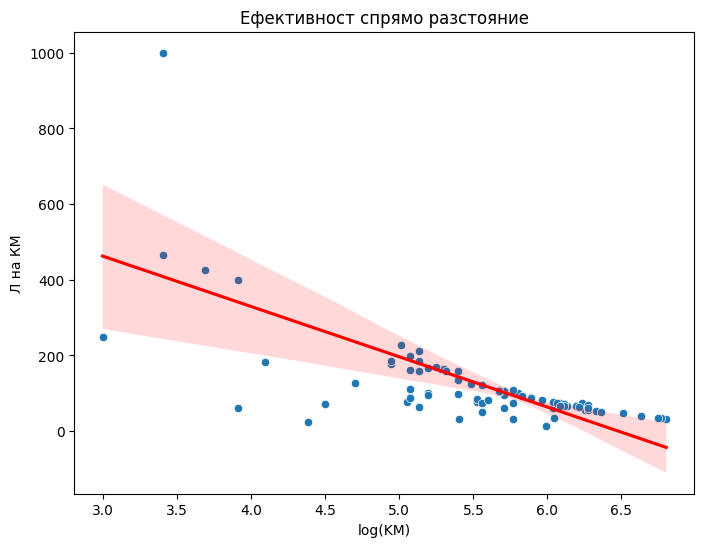

In [239]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=data,
    x='log_KM',
    y='Л_на_КМ'
)

sns.regplot(
    data=data,
    x='log_KM',
    y='Л_на_КМ',
    scatter=False,
    color='red'
)

plt.title('Ефективност спрямо разстояние')
plt.xlabel('log(KM)')
plt.ylabel('Л на КМ')

plt.show()

## Защо използваме log(KM)

### Какъв е проблемът:
Разстоянието (KM) има много голям диапазон:
- къси курсове → 50–100 км
- дълги курсове → 500–800+ км

Това води до:
- изкривена визуализация
- нелинейна зависимост
- трудно сравнение

---

### Какво прави log(KM):
Логаритъмът "свива" големите стойности и прави данните по-равномерни.

Пример:
- 100 км → log ≈ 4.6
- 800 км → log ≈ 6.7

разликата става по-малка и по-управляема

---

### Какво постигаме:
- връзката става по-линейна (по-лесна за анализ)
- намаляваме влиянието на екстремни стойности
- получаваме по-ясен тренд

---

### Как да го тълкуваме:
log(KM) не е нов показател, а трансформация на разстоянието, която ни помага да видим реалната зависимост между разстояние и ефективност.

---

### Извод:
Използваме log(KM), за да направим анализа по-точен и да открием по-ясно зависимостите в данните.

In [240]:
X = data[['log_KM']]
y = data['Л_на_КМ']

model = LinearRegression()
model.fit(X, y)

data['pred'] = model.predict(X)

data = data.replace([np.inf, -np.inf], np.nan)
data['residual'] = data['Л_на_КМ'] - data['pred']

In [241]:
threshold = data['residual'].std()
data['efficiency'] = 'Normal'

data.loc[data['residual'] > threshold, 'efficiency'] = 'Good'
data.loc[data['residual'] < -threshold, 'efficiency'] = 'Bad'

In [242]:
data['efficiency'].value_counts(normalize=True) * 100

efficiency
Normal    89.010989
Bad        8.791209
Good       2.197802
Name: proportion, dtype: float64

In [243]:
data.sort_values('residual').head(10)

,ДАТА,КУРС_ДАТА,ВЪЗЛОЖИТЕЛ,КУРС,БРОЙ_ОБЕКТИ,ПРЕВОЗВАЧ,ШОФЬОР,ВЛЕКАЧ,ЦИСТЕРНА,КМ,...,ПРОМЯНА_ОТ,ПОСЛЕДЕН_ЪПДЕЙТ,ГОДИНА,МЕСЕЦ,ДЕН,Л_на_КМ,log_KM,pred,residual,efficiency
28,20260216-0001,2026-02-16,ОФИС ВАРНА,Варна-Повеляново-Варна,NaN,ЕВРОУЕЙ СЪРВИЗ ООД,ГЕОРГИ ИЛИЕВ ГЕОРГИЕВ,Р9581МА,NaN,50.0,...,Plamen Svetoslavov,2026-04-01 18:46:16.264,2026,2,16,60.000000,3.912023,340.953560,-280.953560,Bad
54,20260312-0004,2026-03-09,ОФИС ВАРНА,НХК-Каблешково-НХК,NaN,ДИРОСИ ООД,СТАНИСЛАВ ДИМИТРОВ ИВАНОВ,А1535ВВ,NaN,80.0,...,Plamen Svetoslavov,2026-04-01 18:46:02.386,2026,3,12,25.000000,4.382027,278.533743,-253.533743,Bad
33,20260223-0001,2026-02-23,ОФИС ВАРНА,варна,NaN,ЕВРОУЕЙ СЪРВИЗ ООД,ГЕОРГИ ИЛИЕВ ГЕОРГИЕВ,CB2201CC,P2849EE,20.0,...,Plamen Svetoslavov,2026-04-01 18:46:16.264,2026,2,23,250.000000,2.995732,462.643473,-212.643473,Bad
18,20260206-0001,2026-02-09,ОФИС ВАРНА,Варна-Суворово-Варна,NaN,"""СИ-ТРАНС БЪЛГАРИЯ"" ЕООД",ТОДОР ДИМИТРОВ ПОПОВ,В9261РА,NaN,90.0,...,Plamen Svetoslavov,2026-04-01 18:46:13.139,2026,2,6,72.222222,4.499810,262.891319,-190.669097,Bad
76,20260327-0006,2026-03-27,ОФИС ВАРНА,Варна-Повеляново-Варна,NaN,ЕВРОУЕЙ СЪРВИЗ ООД,ГЕОРГИ ИЛИЕВ ГЕОРГИЕВ,Р9581МА,Р4961ЕЕ,60.0,...,Plamen Svetoslavov,2026-04-01 18:46:05.951,2026,3,27,183.333333,4.094345,316.739964,-133.406630,Bad
15,20260205-0001,2026-02-04,ОФИС ПЛОВДИВ,Пловдив-горски извор-плодовитово-братя даскало...,NaN,ТРАНС ОЙЛ ЕООД,ХРИСТО ТОДОРЕВ ЗЛАТЕВ,PB5393PX,NaN,170.0,...,Plamen Svetoslavov,2026-04-01 18:48:05.597,2026,2,5,62.941176,5.135798,178.427498,-115.486321,Bad
17,20260205-0003,2026-02-05,ОФИС ПЛОВДИВ,софия-елин пелин-радомир-софия,NaN,СГ ОЙЛ ТРАНСПОРТ ЕООД,СВЕТОСЛАВ ЛЮБЕНОВ,CA5494KC,NaN,156.0,...,Plamen Svetoslavov,2026-04-01 18:48:06.985,2026,2,5,77.564103,5.049856,189.841262,-112.277160,Bad
51,20260312-0001,2026-03-06,ОФИС ВАРНА,Цар Калоян - Близнаци - Ушинци - Островче - Бяла,NaN,ЕВРОУЕЙ СЪРВИЗ ООД,ДАНИЕЛ ПЕНЧЕВ ПЕНЧЕВ,Р7826КН,Р2530ЕЕ,222.0,...,Plamen Svetoslavov,2026-04-01 18:46:02.386,2026,3,12,31.531532,5.402677,142.984080,-111.452548,Bad
16,20260205-0002,2026-02-05,ОФИС ПЛОВДИВ,пловдив-бошуля-пловдив,NaN,ТРАНС ОЙЛ ЕООД,ХРИСТО ТОДОРЕВ ЗЛАТЕВ,PB5393PX,NaN,110.0,...,Plamen Svetoslavov,2026-04-01 18:48:06.985,2026,2,5,127.272727,4.700480,236.240827,-108.968100,Normal
52,20260312-0002,2026-03-07,ОФИС ВАРНА,Варна-Каварна-Варна,NaN,ТРАНС ОЙЛ ЕООД,ДИАН СТОЯНОВ АЛЕКСАНДРОВ,B7902TM,NaN,160.0,...,Plamen Svetoslavov,2026-04-01 18:46:02.386,2026,3,12,87.500000,5.075174,186.478878,-98.978878,Normal
